## Librerias

In [547]:
try:
    import pandas as pd
except ImportError:
    print("Pandas not installed")
    %pip install pandas --user

try:
    import matplotlib.pyplot as plt
except ImportError:
    print("Matplotlib not installed")
    %pip install matplotlib --user

import ssl

ssl._create_default_https_context = ssl._create_unverified_context

In [548]:
import pandas as pd
import matplotlib.pyplot as plt

## Lectura de datos

- [Dataset Qatar 2022: https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data](https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data)

In [549]:
archivo = "https://raw.githubusercontent.com/IgnacioPardo/Tecnologias_Exponenciales_2025/refs/heads/main/qatar.csv"

# Leer datos del archivo
mundial : pd.DataFrame = pd.read_csv(archivo)
mundial

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
0,1,Sun,20-Nov-22,17:00,Al Bayt Stadium,Daniele Orsato,Group A,QATAR,ECUADOR,67372,...,0,1,6,5,0,0,52,72,256,279
1,2,Mon,21-Nov-22,14:00,Khalifa International Stadium,Raphael Claus,Group B,ENGLAND,IRAN,45334,...,0,1,8,13,0,0,63,72,139,416
2,3,Mon,21-Nov-22,17:00,Al Thumama Stadium,Wilton Sampaio,Group A,SENEGAL,NETHERLANDS,41721,...,0,0,9,15,0,0,63,73,263,251
3,4,Mon,21-Nov-22,20:00,Ahmed bin Ali Stadium,Abdulrahman Ibrahim Al Jassim,Group B,UNITED STATES,WALES,43418,...,0,1,7,7,0,0,81,72,242,292
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,60,Sat,10-Dec-22,20:00,Al Bayt Stadium,Wilton Sampaio,Quarter-final,ENGLAND,FRANCE,68895,...,1,0,9,15,0,0,49,54,193,308
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,1,0,12,10,0,0,85,63,321,260
61,62,Wed,14-Dec-22,20:00,Al Bayt Stadium,Cesar Ramos,Semi-Final,FRANCE,MOROCCO,68294,...,0,0,13,14,0,0,72,47,328,218
62,63,Sat,17-Dec-22,16:00,Khalifa International Stadium,Abdulrahman Ibrahim Al Jassim,Play-off for third place,CROATIA,MOROCCO,44137,...,0,0,7,14,0,0,75,72,288,277


In [550]:
# Cuantos partidos se jugaron?
# Completar
mundial.shape[0]

64

In [551]:
# Que datos tiene el dataset? (Pista: usar .info(), .describe(), .columns, .head())
# Checkear columnas
# Completar
mundial.columns

Index(['match_no', 'day_of_week', 'date', 'hour', 'venue', 'referee', 'group',
       '1', '2', 'attendance', '1_xg', '2_xg', '1_poss', '2_poss', '1_goals',
       '2_goals', 'score', '1_attempts', '2_attempts', '1_conceded',
       '2_conceded', '1_goal_inside_penalty_area',
       '2_goal_inside_penalty_area', '1_goal_outside_penalty_area',
       '2_goal_outside_penalty_area', '1_ontarget', '2_ontarget',
       '1_offtarget', '2_offtarget', '1_attempts_inside_penalty_area',
       '2_attempts_inside_penalty_area', '1_attempts_outside_penalty_area',
       '2_attempts_outside_penalty_area', '1_yellow_cards', '2_yellow_cards',
       '1_red_cards', '2_red_cards', 'faul_against_1', 'faul_against_2',
       '1_offsides', '2_offsides', '1_passes', '2_passes',
       '1_passes_compeletd', '2_passes_compeletd', '1_corners', '2_corners',
       '1_free_kicks', '2_free_kicks', '1_panelties_scored',
       '2_panelties_scored', '1_goal_prevented', '2_goal_prevented',
       '1_own_goal', '2_o

## Analisis

### Primera Parte

In [552]:
# Cuantas selecciones participaron?
# Completar
mundial["1"].nunique()

32

In [553]:
# Cuantas fases tiene el mundial?
# Completar
mundial["group"].nunique()

13

In [554]:
# Cual fue la "attendance" promedio por partido?
# Completar
mundial["attendance"].mean()

np.float64(53191.4375)

In [555]:
# Cual fue el partido con mas diferencia de goles?
# Completar
columnas_selecciones = ["1", "2"]
mundial.loc[(mundial["1_goals"] - mundial["2_goals"]).abs().idxmax(), columnas_selecciones]

1         SPAIN
2    COSTA RICA
Name: 10, dtype: str

In [556]:
# Cual es la selección que mas penales metió?
# Completar
mundial.groupby("1")["1_panelties_scored"].sum().idxmax()

'ARGENTINA'

In [557]:
# Cual es la selección que mas penales le hicieron?
# Completar
mundial.groupby("2")["1_panelties_scored"].sum().idxmax()

'FRANCE'

### Segunda Parte

In [558]:
equipo : str = "ARGENTINA"

In [559]:
# Seleccionar todos los partidos que jugo el equipo de "local"
# Completar
columnas=["1", "2"]
filtroLocal : pd.Series = mundial["1"] == equipo
print(mundial.loc[filtroLocal, columnas])

            1             2
4   ARGENTINA  SAUDI ARABIA
23  ARGENTINA        MEXICO
49  ARGENTINA     AUSTRALIA
60  ARGENTINA       CROATIA
63  ARGENTINA        FRANCE


In [560]:
# Seleccionar todos los partidos que jugo el equipo de "visitante"
# Completar
columnas=["1", "2"]
filtroLocal : pd.Series = mundial["2"] == equipo
print(mundial.loc[filtroLocal, columnas])

              1          2
38       POLAND  ARGENTINA
57  NETHERLANDS  ARGENTINA


In [561]:
# Seleccionar todos los partidos que jugo el equipo (de "local" o "visitante")
# Completar
columnas=["1", "2"]
filtroLocal : pd.Series = mundial.loc[(mundial["1"] == equipo) | (mundial["2"] == equipo), columnas]
print(filtroLocal)

              1             2
4     ARGENTINA  SAUDI ARABIA
23    ARGENTINA        MEXICO
38       POLAND     ARGENTINA
49    ARGENTINA     AUSTRALIA
57  NETHERLANDS     ARGENTINA
60    ARGENTINA       CROATIA
63    ARGENTINA        FRANCE


In [562]:
# Cuantos goles hizo el equipo en total (obtener los goles metidos de local y sumarlos con los goles metidos de visitante)
# Completar

goles : int = mundial.loc[mundial["1"] == equipo, "1_goals"].sum() + mundial.loc[mundial["2"] == equipo, "2_goals"].sum()
print(goles)

15


In [563]:
# Cuantos goles hizo el equipo en promedio
# Completar
partidos_jugados : int = mundial.loc[(mundial["1"] == equipo) | (mundial["2"] == equipo)].shape[0]
goles_promedio : float = goles / partidos_jugados
print(goles_promedio)

2.142857142857143


In [564]:
# Cuantos partidos gano el equipo
# Completar
partidos_ganados : int = mundial.loc[((mundial["1"] == equipo) & (mundial["1_goals"] > mundial["2_goals"])) | ((mundial["2"] == equipo) & (mundial["2_goals"] > mundial["1_goals"]))].shape[0]
print(partidos_ganados)

    

4


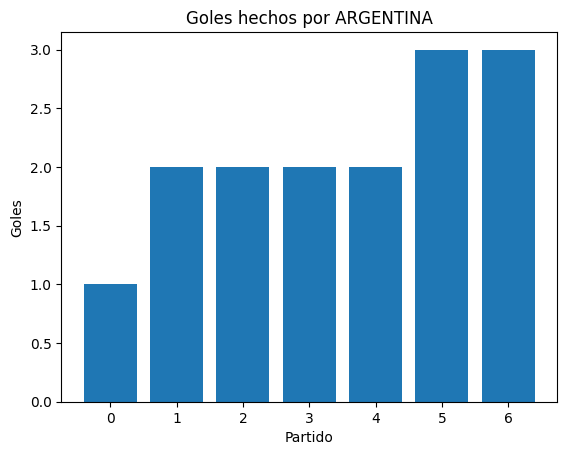

In [565]:
# Graficar los goles hechos por el equipo en cada partido

fig, ax = plt.subplots()

goles = []
for i in range(mundial.shape[0]):
    if mundial.iloc[i]['1'] == equipo:
        goles.append(mundial.iloc[i]['1_goals'])
    elif mundial.iloc[i]['2'] == equipo:
        goles.append(mundial.iloc[i]['2_goals'])
ax.bar(range(len(goles)), goles)
ax.set_title("Goles hechos por " + equipo)
ax.set_xlabel("Partido")
ax.set_ylabel("Goles")
plt.show()
# Completar

### Tercera Parte

In [566]:
# Contar cuantos goles hizo cada equipo en total en el mundial
# Completar

goles:int = mundial["1_goals"].groupby(mundial["1"]).sum() + mundial["2_goals"].groupby(mundial["2"]).sum()
goles.sort_values(ascending=False)

1
FRANCE            16
ARGENTINA         15
ENGLAND           13
PORTUGAL          12
NETHERLANDS       10
SPAIN              9
BRAZIL             8
CROATIA            8
GERMANY            6
MOROCCO            6
JAPAN              5
SWITZERLAND        5
SERBIA             5
SENEGAL            5
KOREA REPUBLIC     5
GHANA              5
IRAN               4
AUSTRALIA          4
ECUADOR            4
CAMEROON           4
UNITED STATES      3
COSTA RICA         3
SAUDI ARABIA       3
POLAND             3
CANADA             2
MEXICO             2
URUGUAY            2
QATAR              1
DENMARK            1
BELGIUM            1
TUNISIA            1
WALES              1
dtype: int64

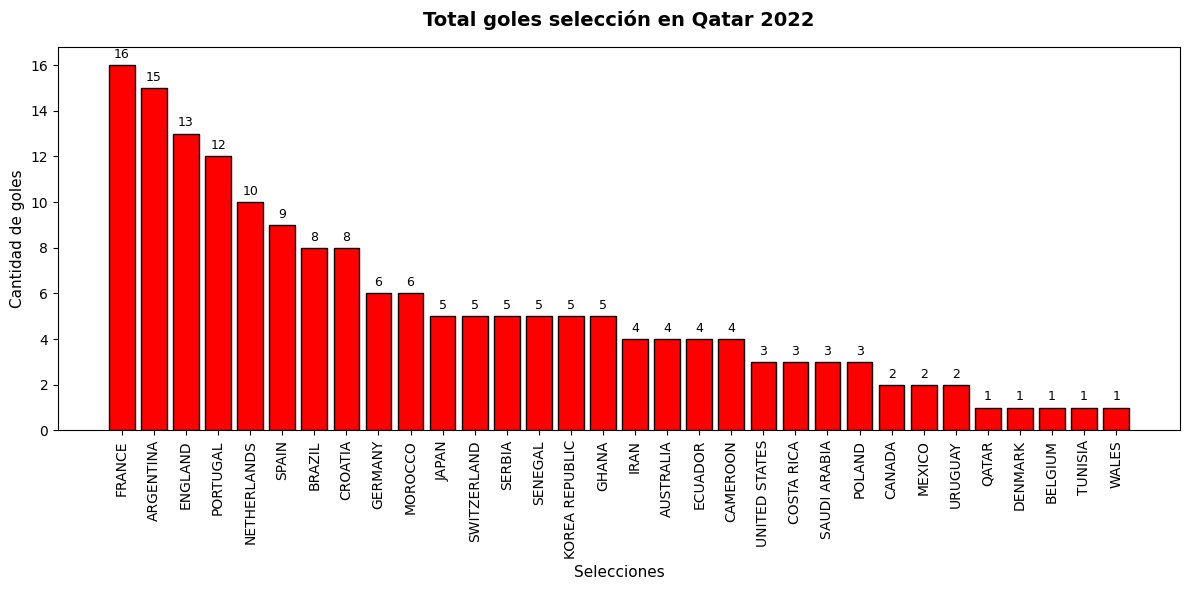

In [567]:
# Graficar los goles por equipo en todo el mundial

goles_por_equipo = mundial["1_goals"].groupby(mundial["1"]).sum() + mundial["2_goals"].groupby(mundial["2"]).sum()
goles_ordenados = goles_por_equipo.sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 6)) 
barras = ax.bar(goles_ordenados.index, goles_ordenados.values, color="red", edgecolor="black")
ax.set_title("Total goles selección en Qatar 2022", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Selecciones", fontsize=11)
ax.set_ylabel("Cantidad de goles", fontsize=11)
plt.xticks(rotation=90)
ax.bar_label(barras, padding=3, fontsize=9)
plt.tight_layout()
plt.show()

In [568]:
# Cual es el equipo que hizo mas goles en el mundial?
# Completar
goles[goles == goles.max()]

1
FRANCE    16
dtype: int64

In [569]:
# Por cada partido, cual fue la diferencia de goles?
# Completar
diferencia = (mundial['1_goals']-mundial['2_goals'])
mundial[['1', '2']].assign(diferencia=diferencia)

,1,2,diferencia
0,QATAR,ECUADOR,-2
1,ENGLAND,IRAN,4
2,SENEGAL,NETHERLANDS,-2
3,UNITED STATES,WALES,0
4,ARGENTINA,SAUDI ARABIA,-1
...,...,...,...
59,ENGLAND,FRANCE,-1
60,ARGENTINA,CROATIA,3
61,FRANCE,MOROCCO,2
62,CROATIA,MOROCCO,1


In [570]:
# Por cada partido, cual fue el equipo que gano?
# Completar
ganadores =[]
for i in range(mundial.shape[0]):
  if(mundial.iloc[i]['1_goals'] > mundial.iloc[i]['2_goals']):
    ganadores.append(mundial.iloc[i]['1'])
  elif (mundial.iloc[i]['1_goals'] < mundial.iloc[i]['2_goals']):
      ganadores.append(mundial.iloc[i]['2'])
  else:
      ganadores.append("EMPATE")
mundial["ganadores"] = ganadores
mundial[["1", "2", "ganadores"]]

,1,2,ganadores
0,QATAR,ECUADOR,ECUADOR
1,ENGLAND,IRAN,ENGLAND
2,SENEGAL,NETHERLANDS,NETHERLANDS
3,UNITED STATES,WALES,EMPATE
4,ARGENTINA,SAUDI ARABIA,SAUDI ARABIA
...,...,...,...
59,ENGLAND,FRANCE,FRANCE
60,ARGENTINA,CROATIA,ARGENTINA
61,FRANCE,MOROCCO,FRANCE
62,CROATIA,MOROCCO,CROATIA


In [571]:
# En cada fase del mundial, cual fue el equipo que hizo mas goles?
# Completar
goles_1 = mundial[['group', '1', '1_goals']].rename(columns={'1': 'equipo', '1_goals': 'goles'})
goles_2 = mundial[['group', '2', '2_goals']].rename(columns={'2': 'equipo', '2_goals': 'goles'})

pd.concat([goles_1, goles_2]).groupby(['group', 'equipo'])['goles'].sum().groupby('group').idxmax()

group
Final                                        (Final, ARGENTINA)
Group A                                  (Group A, NETHERLANDS)
Group B                                      (Group B, ENGLAND)
Group C                                    (Group C, ARGENTINA)
Group D                                       (Group D, FRANCE)
Group E                                        (Group E, SPAIN)
Group F                                      (Group F, CROATIA)
Group G                                       (Group G, SERBIA)
Group H                                     (Group H, PORTUGAL)
Play-off for third place    (Play-off for third place, CROATIA)
Quarter-final                        (Quarter-final, ARGENTINA)
Round of 16                             (Round of 16, PORTUGAL)
Semi-Final                              (Semi-Final, ARGENTINA)
Name: goles, dtype: object

### Tercera Parte

C:\Users\KRDG\AppData\Local\Temp\ipykernel_6296\2636936614.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  fechas_convertidas = pd.to_datetime(mundial["date"])


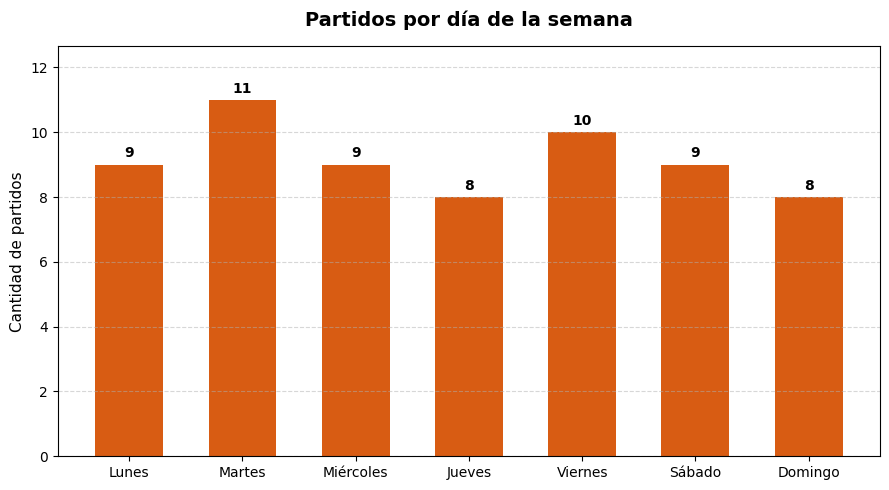

In [572]:
# Armar un gráfico a partir de algun nuevo análisis que se te ocurra
# Completar
fechas_convertidas = pd.to_datetime(mundial["date"])
dias_ingles = fechas_convertidas.dt.day_name()
mapa_dias = {
    'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
    'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}
mundial["dia_semana"] = dias_ingles.map(mapa_dias)
orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
partidos_por_dia = mundial["dia_semana"].value_counts().reindex(orden_dias)
fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.bar(partidos_por_dia.index, partidos_por_dia.values, color="#D85C13", width=0.6)
ax.bar_label(barras, padding=3, fontweight='bold')
ax.set_title("Partidos por día de la semana", fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel("Cantidad de partidos", fontsize=11)
ax.set_ylim(0, max(partidos_por_dia.values) * 1.15) 
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()